In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer, InputExample
from sentence_transformers.sentence_transformer.losses import CosineSimilarityLoss
from sentence_transformers.sentence_transformer.evaluation import EmbeddingSimilarityEvaluator
from sentence_transformers.sentence_transformer.datasets import SentencesDataset

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity

import warnings

warnings.filterwarnings("ignore")

print("Libraries imported!")

Libraries imported!


In [2]:
# Load the cleaned ATS pairs dataset
df = pd.read_csv('./resume_jd_pairs.csv')
print(f'Loaded: {len(df)} pairs')
print(f'\nLabel distribution:')
print(df['match_label'].value_counts())
print(f'\nScore range: {df["match_score"].min():.2f} – {df["match_score"].max():.2f}')
df.head(3)


Loaded: 310 pairs

Label distribution:
match_label
high      116
low        97
medium     97
Name: count, dtype: int64

Score range: 0.00 – 1.00


,resume_text,job_description,match_score,match_label
0,Results-driven Computer Science graduate with ...,"We are hiring a Data Analyst to collect, clean...",0.95,high
1,Motivated software developer with experience b...,"Seeking a Backend Java Developer to design, de...",0.93,high
2,Computer Science graduate with strong foundati...,Looking for a Frontend Developer skilled in Re...,0.91,high


In [3]:
#Train / Val / Test Split
#Stratify by match_label so each split has balanced high/medium/low

train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['match_label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['match_label']
)

print(f'Train:      {len(train_df)} pairs')
print(f'Validation: {len(val_df)} pairs')
print(f'Test:       {len(test_df)} pairs')
print()

# Verify each split has all 3 labels
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name} label dist: {split["match_label"].value_counts().to_dict()}')


Train:      217 pairs
Validation: 46 pairs
Test:       47 pairs

Train label dist: {'high': 81, 'medium': 68, 'low': 68}
Val label dist: {'high': 17, 'medium': 15, 'low': 14}
Test label dist: {'high': 18, 'low': 15, 'medium': 14}


In [4]:
#Convert to InputExample format — sentence-transformers expects this
#text1 = resume, text2 = job description, label = match_score (float 0-1)

train_examples = [
    InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score']))
    for _, row in train_df.iterrows()
]

val_examples = [
    InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score']))
    for _, row in val_df.iterrows()
]

print(f'Train examples: {len(train_examples)}')
print(f'Val examples:   {len(val_examples)}')
print(f'\nSample InputExample:')
print(f'  text1 (resume): {train_examples[0].texts[0][:80]}...')
print(f'  text2 (JD):     {train_examples[0].texts[1][:80]}...')
print(f'  label:          {train_examples[0].label}')


Train examples: 217
Val examples:   46

Sample InputExample:
  text1 (resume): Passionate Android Developer with 5 years of professional experience specialisin...
  text2 (JD):     An exciting opportunity exists for a seasoned Android Developer to join a high-g...
  label:          0.57


In [5]:
#Base Model Baseline
print('Loading base BERT model...')
base_model = SentenceTransformer("all-MiniLM-L6-v2")
print('Loaded.')


Loading base BERT model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded.


In [6]:
# Evaluate base model on test set BEFORE fine-tuning
# This is our baseline, fine-tuning should beat this
print('Evaluating base model on test set...')

base_preds = []
for _, row in test_df.iterrows():
    emb1 = base_model.encode(row['resume_text'])
    emb2 = base_model.encode(row['job_description'])
    sim = cosine_similarity(np.array([emb1]), np.array([emb2]))[0][0]
    base_preds.append(float(sim))

base_mae  = mean_absolute_error(test_df['match_score'], base_preds)
base_rmse = np.sqrt(mean_squared_error(test_df['match_score'], base_preds))

print(f'\nBase Model — Test Set Performance')
print(f'  MAE:  {base_mae:.4f}')
print(f'  RMSE: {base_rmse:.4f}')
print()
print('Goal: fine-tuning should reduce MAE below this number.')

Evaluating base model on test set...

Base Model — Test Set Performance
  MAE:  0.2068
  RMSE: 0.2612

Goal: fine-tuning should reduce MAE below this number.


In [7]:
#Fine-Tune BERT

# Fresh model instance for fine-tuning (don't reuse base_model)
model = SentenceTransformer("all-MiniLM-L6-v2")
# Convert list[InputExample] into a Dataset expected by DataLoader
train_dataset = SentencesDataset(train_examples, model=model)

# DataLoader, shuffles training data each epoch
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=16)

# CosineSimilarityLoss: trains the model so that
# cosine_similarity(embed(resume), embed(jd)) ≈ match_score
train_loss = CosineSimilarityLoss(model)

# Evaluator runs on val set after each evaluation_steps
evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    val_examples, name='ats-val'
)

print('Training setup ready.')
print(f'  Batch size:   16')
print(f'  Train pairs:  {len(train_examples)}')
print(f'  Steps/epoch:  {len(train_dataloader)}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Training setup ready.
  Batch size:   16
  Train pairs:  217
  Steps/epoch:  14


In [8]:
total_steps   = len(train_dataloader) * 10
warmup_steps  = int(total_steps * 0.1)

print(f'Total steps:  {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print(f'\nStarting fine-tuning...\n')

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=10,
    evaluation_steps=len(train_dataloader),
    warmup_steps=warmup_steps,
    output_path='models/finetuned-bert',
    save_best_model=True,
    show_progress_bar=True
)

print('\nFine-tuning complete!')

Total steps:  140
Warmup steps: 14

Starting fine-tuning...



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Ats-val Pearson Cosine,Ats-val Spearman Cosine
14,No log,No log,0.779407,0.737907
28,No log,No log,0.787271,0.734452
42,No log,No log,0.797089,0.756849
56,No log,No log,0.798837,0.754134
70,No log,No log,0.798958,0.753332
84,No log,No log,0.801768,0.759193
98,No log,No log,0.801922,0.759255
112,No log,No log,0.801297,0.757404
126,No log,No log,0.801501,0.757095
140,No log,No log,0.801514,0.757095


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuning complete!


In [9]:
#Evaluate Fine-Tuned Model

finetuned_model = SentenceTransformer('models/finetuned-bert')
print('Fine-tuned model loaded.')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Fine-tuned model loaded.


In [10]:
ft_preds = []
for _, row in test_df.iterrows():
    emb1 = finetuned_model.encode(row['resume_text'])
    emb2 = finetuned_model.encode(row['job_description'])
    sim  = cosine_similarity([emb1], [emb2])[0][0]
    ft_preds.append(float(sim))

ft_mae  = mean_absolute_error(test_df['match_score'], ft_preds)
ft_rmse = np.sqrt(mean_squared_error(test_df['match_score'], ft_preds))

print(f'\nFine-tuned Model — Test Set Performance')
print(f'  MAE:  {ft_mae:.4f}')
print(f'  RMSE: {ft_rmse:.4f}')


Fine-tuned Model — Test Set Performance
  MAE:  0.1616
  RMSE: 0.2065


In [11]:
# Side-by-side comparison
print('=' * 50)
print('MODEL COMPARISON')
print('=' * 50)
print(f'  Base MAE:         {base_mae:.4f}')
print(f'  Fine-tuned MAE:   {ft_mae:.4f}')
print(f'  Improvement:      {(base_mae - ft_mae)/base_mae*100:.1f}%')
print('=' * 50)

MODEL COMPARISON
  Base MAE:         0.2068
  Fine-tuned MAE:   0.1616
  Improvement:      21.9%


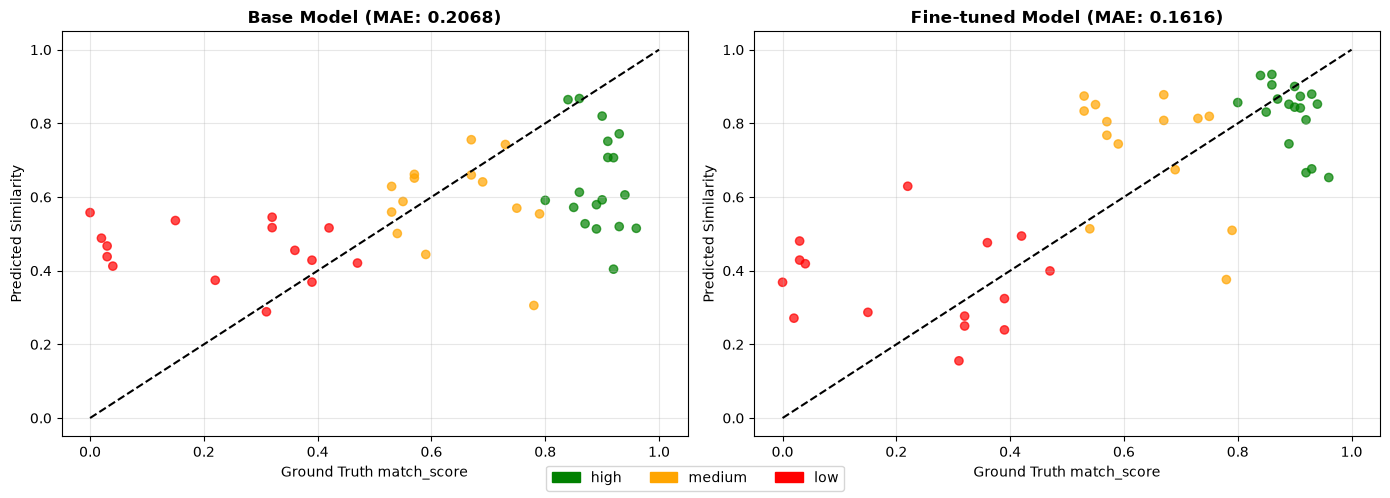

In [12]:
# Scatter plots: base vs fine-tuned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = test_df['match_label'].map({'low':'red','medium':'orange','high':'green'})

for ax, preds, title, mae in [
    (axes[0], base_preds, 'Base Model', base_mae),
    (axes[1], ft_preds,   'Fine-tuned Model', ft_mae),
]:
    ax.scatter(test_df['match_score'], preds, c=colors, alpha=0.7)
    ax.plot([0,1],[0,1],'k--', label='Perfect')
    ax.set_xlabel('Ground Truth match_score')
    ax.set_ylabel('Predicted Similarity')
    ax.set_title(f'{title} (MAE: {mae:.4f})', fontweight='bold')
    ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(color='green', label='high'),
    Patch(color='orange', label='medium'),
    Patch(color='red', label='low'),
], loc='lower center', ncol=3)
plt.tight_layout()
plt.show()

In [13]:
import json

metadata = {
    'base_model':       'all-mpnet-base-v2',
    'dataset':          'merged_dataset_clean.csv',
    'total_pairs':      len(df),
    'train_pairs':      len(train_df),
    'val_pairs':        len(val_df),
    'test_pairs':       len(test_df),
    'epochs':           10,
    'batch_size':       16,
    'base_mae':         round(float(base_mae), 4),
    'finetuned_mae':    round(float(ft_mae), 4),
    'improvement_pct':  round((base_mae - ft_mae) / base_mae * 100, 2),
}

with open('models/finetuned-bert/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: models/finetuned-bert/')
print(json.dumps(metadata, indent=2))

Saved: models/finetuned-bert/
{
  "base_model": "all-mpnet-base-v2",
  "dataset": "merged_dataset_clean.csv",
  "total_pairs": 310,
  "train_pairs": 217,
  "val_pairs": 46,
  "test_pairs": 47,
  "epochs": 10,
  "batch_size": 16,
  "base_mae": 0.2068,
  "finetuned_mae": 0.1616,
  "improvement_pct": 21.88
}


In [14]:
#Production Pipeline Test

def score_resume_against_jd(resume_text, jd_text, model):
 
    emb_resume = model.encode(resume_text, convert_to_numpy=True)
    emb_jd     = model.encode(jd_text,     convert_to_numpy=True)
    score      = cosine_similarity([emb_resume], [emb_jd])[0][0]
    return float(score)


# Test with realistic cases
test_cases = [
    {
        'label':  'HIGH match expected',
        'resume': 'Senior Python developer with 6 years experience. Built REST APIs using FastAPI and Django. Proficient in PostgreSQL, Docker, and AWS deployment.',
        'jd':     'We need a Python backend engineer with FastAPI or Django experience. Must know SQL databases and cloud deployment.',
    },
    {
        'label':  'MEDIUM match expected',
        'resume': 'Frontend developer with 3 years React and TypeScript experience. Some Node.js and Express for small APIs.',
        'jd':     'Full stack engineer needed. React frontend required, strong Python backend preferred. 4+ years experience.',
    },
    {
        'label':  'LOW match expected',
        'resume': 'Executive Chef with 12 years experience in fine dining. Expert in French cuisine, menu planning, and kitchen management.',
        'jd':     'Data Scientist with Python, machine learning, and SQL experience required.',
    },
]

print('Production Pipeline Test')
print('=' * 60)
for case in test_cases:
    score = score_resume_against_jd(case['resume'], case['jd'], finetuned_model)
    label = 'HIGH' if score > 0.70 else 'MEDIUM' if score > 0.45 else 'LOW'
    print(f"\n{case['label']}")
    print(f"  Predicted score: {score:.4f}  →  {label}")


Production Pipeline Test

HIGH match expected
  Predicted score: 0.8090  →  HIGH

MEDIUM match expected
  Predicted score: 0.7439  →  HIGH

LOW match expected
  Predicted score: 0.2138  →  LOW
